## 1. Data Ingestion
Remaining Useful Life Prediction for Lithium-Ion Batteries Using Machine Learning Techniques

**Reasoning**:
Now that the '1. Data Ingestion' section header is in place, I need to move the code cell `0c06f842` (which handles unzipping) to immediately follow this section header to organize the notebook as requested.



In [ ]:
from google.colab import files
uploaded = files.upload()


Saving lifestyle_RUL_7500_ml.csv to lifestyle_RUL_7500_ml.csv


## 1.1. Initial Data Inspection

In [ ]:
import zipfile
import glob
import os

# Unzip all uploaded zip files, ensuring they are extracted to appropriate directories
zip_files = glob.glob('*.zip')
if not zip_files:
    print("No zip files found to unzip. Please ensure zip files are uploaded.")
else:
    for zip_file_name in zip_files:
        try:
            # Create a directory named after the zip file (without .zip extension) for extraction
            extract_dir = os.path.splitext(zip_file_name)[0]
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
            print(f"Extracted {zip_file_name} to {extract_dir}/")
        except zipfile.BadZipFile:
            print(f"Warning: {zip_file_name} is not a valid zip file. Skipping.")
        except Exception as e:
            print(f"An error occurred while unzipping {zip_file_name}: {e}")

No zip files found to unzip. Please ensure zip files are uploaded.


# 2. Data Preprocessing & Feature Engineering

**Reasoning**:
Now that the '2. Data Preprocessing & Feature Engineering' section header is in place, I will extract the imports, settings, helper function, and data consolidation logic from the original preprocessing cell (`28b1934d`) into a new code cell and place it immediately after this header. This aligns with the refactoring instructions to move core preprocessing logic and helper functions to this section.



# 3. Exploratory Data Analysis (EDA)

In [ ]:
# 1. Inspection for the Discharge Phase (7,500 samples)
print("\n--- Processed Discharge DataFrame Info ---")
processed_discharge.info()

# 2. Inspection for the Load Phase (7,500 samples)
print("\n--- Processed Load DataFrame Head ---")
# Using display() is great for Jupyter/Colab environments
display(processed_load.head())


--- Processed Discharge DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   Time         7500 non-null   timedelta64[ns]
 1   Cycle_ID     7500 non-null   float64        
 2   Current      7500 non-null   float64        
 3   Temperature  7500 non-null   float64        
 4   V_avg        7500 non-null   float64        
 5   V_std        7500 non-null   float64        
 6   RUL          7500 non-null   float64        
dtypes: float64(6), timedelta64[ns](1)
memory usage: 410.3 KB

--- Processed Load DataFrame Head ---


,Time,Cycle_ID,Current,Temperature,V_avg,V_std


In [ ]:
import pandas as pd

# 1. Load the master dataset we generated
# This file contains all 7500 samples for both phases
master_df = pd.read_csv('lifestyle_RUL_7500_ml.csv')

# 2. Re-populate processed_load
# We take cycle, RUL, and everything starting with 'L_'
l_cols = ['cycle', 'RUL'] + [c for c in master_df.columns if c.startswith('L_')]
processed_load = master_df[l_cols].copy()
# Standardize names: 'L_Temp' -> 'Temperature', etc.
processed_load.columns = [c.replace('L_', '') for c in processed_load.columns]

# 3. Re-populate processed_discharge
# We take cycle, RUL, and everything starting with 'D_'
d_cols = ['cycle', 'RUL'] + [c for c in master_df.columns if c.startswith('D_')]
processed_discharge = master_df[d_cols].copy()
# Standardize names: 'D_Temp' -> 'Temperature', etc.
processed_discharge.columns = [c.replace('D_', '') for c in processed_discharge.columns]

# 4. Final Shape Verification
print(f"Shape of processed_load: {processed_load.shape}")
print(f"Shape of processed_discharge: {processed_discharge.shape}")

Shape of processed_load: (7500, 9)
Shape of processed_discharge: (7500, 9)


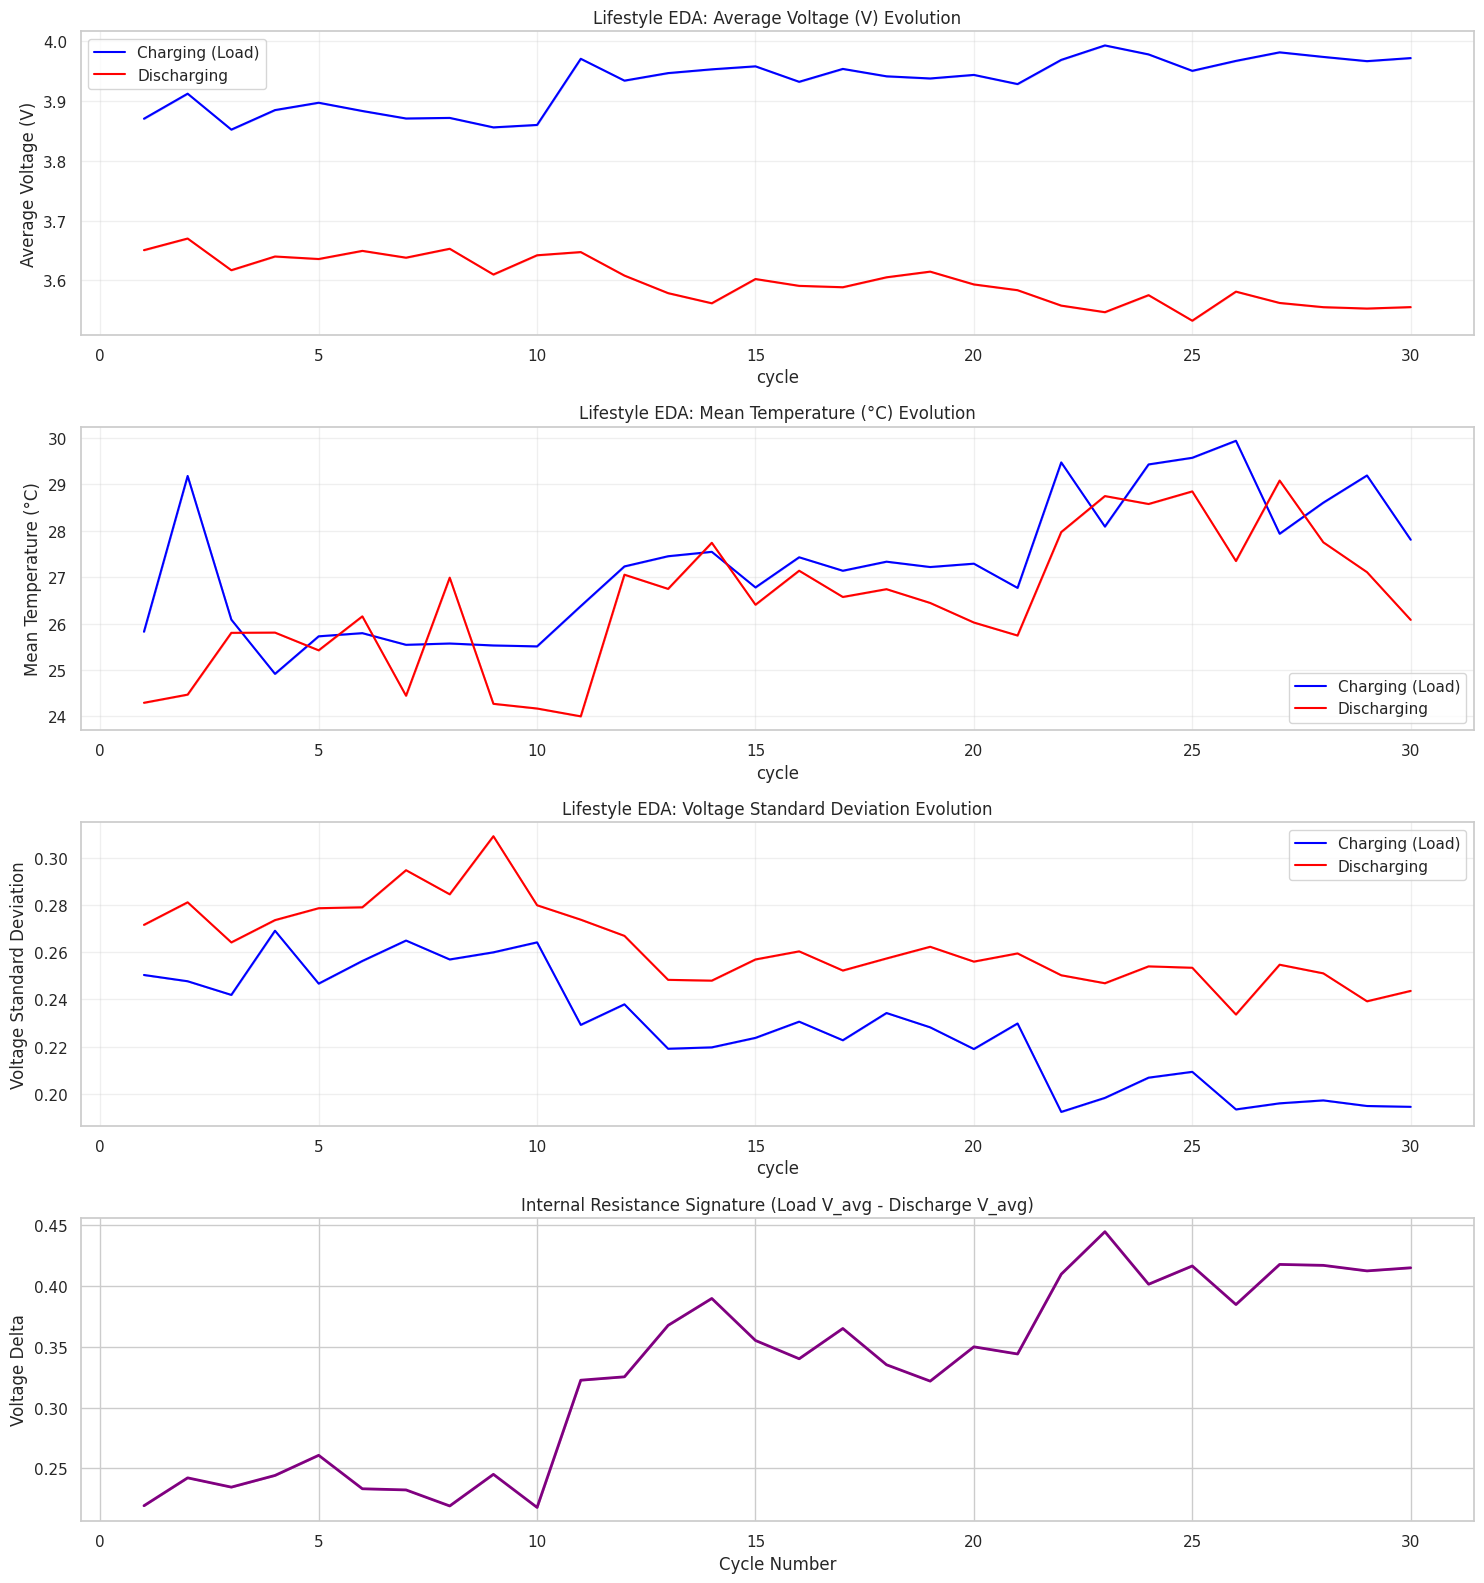

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('lifestyle_RUL_7500_ml.csv')

# Corrected feature pairs (Matching L_Temp and D_Temp)
feature_pairs = [
    ('L_V_avg', 'D_V_avg', 'Average Voltage (V)'),
    ('L_Temp', 'D_Temp', 'Mean Temperature (°C)'),
    ('L_V_std', 'D_V_std', 'Voltage Standard Deviation')
]

fig, axes = plt.subplots(len(feature_pairs) + 1, 1, figsize=(15, 16))

for i, (l_feat, d_feat, label) in enumerate(feature_pairs):
    sns.lineplot(data=df, x='cycle', y=l_feat, ax=axes[i], label='Charging (Load)', color='blue')
    sns.lineplot(data=df, x='cycle', y=d_feat, ax=axes[i], label='Discharging', color='red')
    axes[i].set_title(f'Lifestyle EDA: {label} Evolution')
    axes[i].set_ylabel(label)
    axes[i].grid(True, alpha=0.3)

# Plotting the V_Delta (The key predictor for RUL)
sns.lineplot(data=df, x='cycle', y='V_Delta', ax=axes[-1], color='purple', linewidth=2)
axes[-1].set_title('Internal Resistance Signature (Load V_avg - Discharge V_avg)')
axes[-1].set_ylabel('Voltage Delta')
axes[-1].set_xlabel('Cycle Number')

plt.tight_layout()
plt.show()

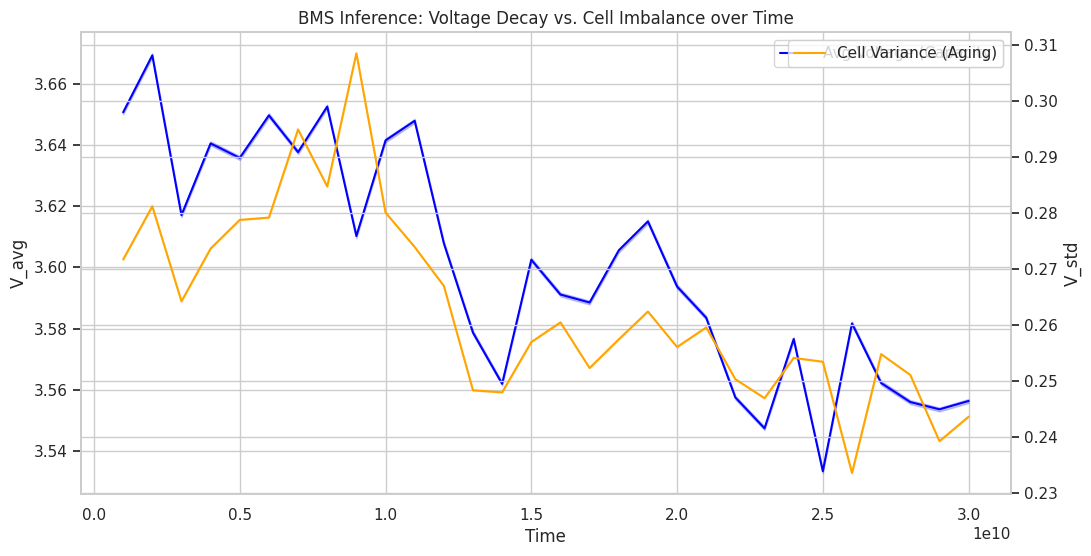

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# B. Inference Graph: Capacity vs. Aging Signature
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=processed_discharge, x='Time', y='V_avg', color='blue', label='Avg Voltage (Capacity)')
ax2 = ax.twinx()
sns.lineplot(data=processed_discharge, x='Time', y='V_std', color='orange', label='Cell Variance (Aging)', ax=ax2)
plt.title('BMS Inference: Voltage Decay vs. Cell Imbalance over Time')
plt.show()

## Create Feature Correlation Analysis Plots

### Subtask:
Extract the correlation matrix for load from the original cell `28b1934d` into a new code cell and place it under the '3.2. Feature Correlation Analysis' section.

**Reasoning**:
I need to extract the plotting code for the 'C. Correlation Matrix for Load (Charging Phase)' from the original preprocessing cell and place it in a new code cell under the '3.2. Feature Correlation Analysis' section, as per the refactoring instructions. I'll also add an import statement for plotting libraries to make the cell self-contained, though they might already be imported globally.



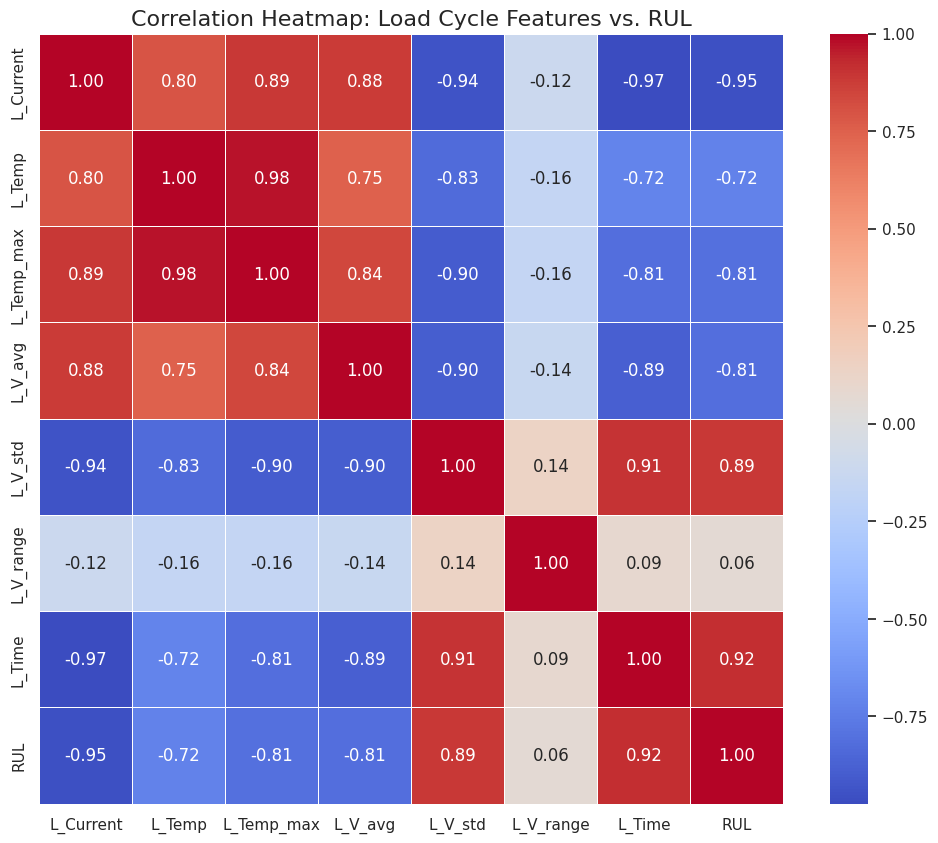

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the "Strong" ML dataset
df = pd.read_csv('lifestyle_RUL_7500_ml.csv')

# 2. Isolate Load features (starting with L_) and the target RUL
load_cols = [col for col in df.columns if col.startswith('L_')] + ['RUL']
load_df = df[load_cols]

# 3. Calculate the Pearson Correlation Matrix
corr_matrix = load_df.corr()

# 4. Generate the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Load Cycle Features vs. RUL', fontsize=16)
plt.show()

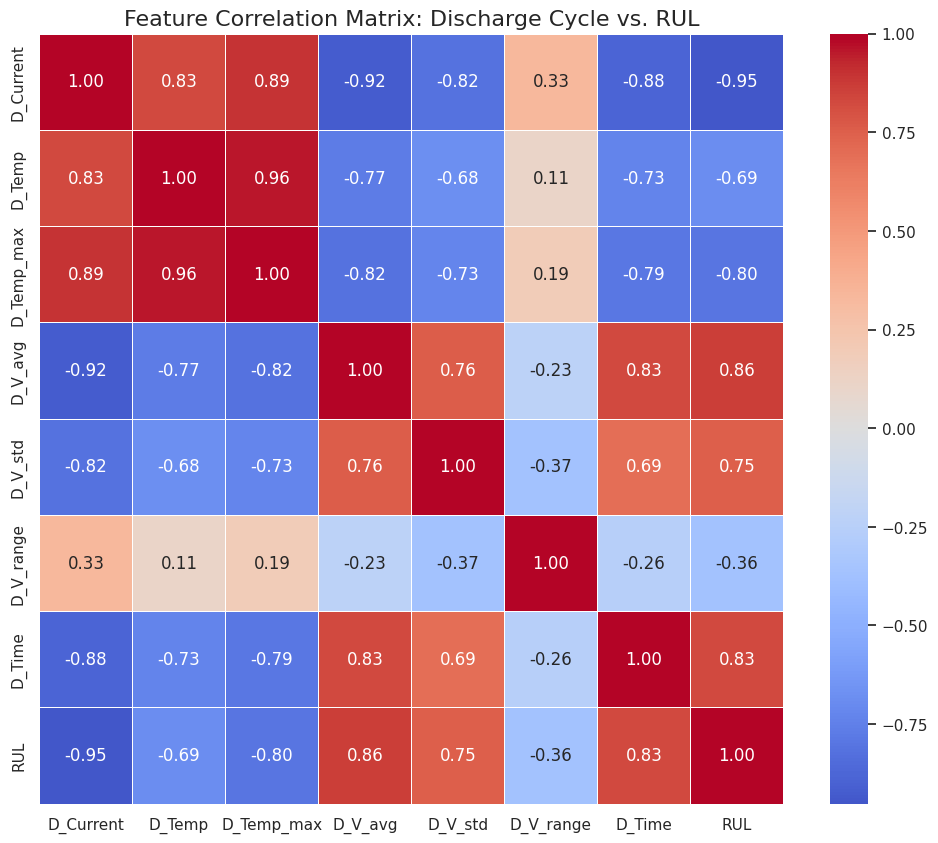

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the ML dataset (Wide Format)
df = pd.read_csv('lifestyle_RUL_7500_ml.csv')

# 2. Identify Discharge-specific features and include RUL
# We use columns starting with 'D_' and the target 'RUL'
discharge_features = [col for col in df.columns if col.startswith('D_')]
corr_cols = discharge_features + ['RUL']

# 3. Create the Heatmap
plt.figure(figsize=(12, 10))
corr = df[corr_cols].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt=".2f",
            linewidths=0.5)

plt.title('Feature Correlation Matrix: Discharge Cycle vs. RUL', fontsize=16)
plt.show()

## Move Temperature Distribution Box Plot

### Subtask:
Move the existing code cell `MZBbQjjsc9Mu` (Temperature Distribution Box Plot) under the '3.3. Distribution Analysis' section.

**Reasoning**:
Now that the markdown header for '3.3. Distribution Analysis' has been added, I will move the existing code cell `MZBbQjjsc9Mu` (Temperature Distribution Box Plot) by recreating its content under this new section.



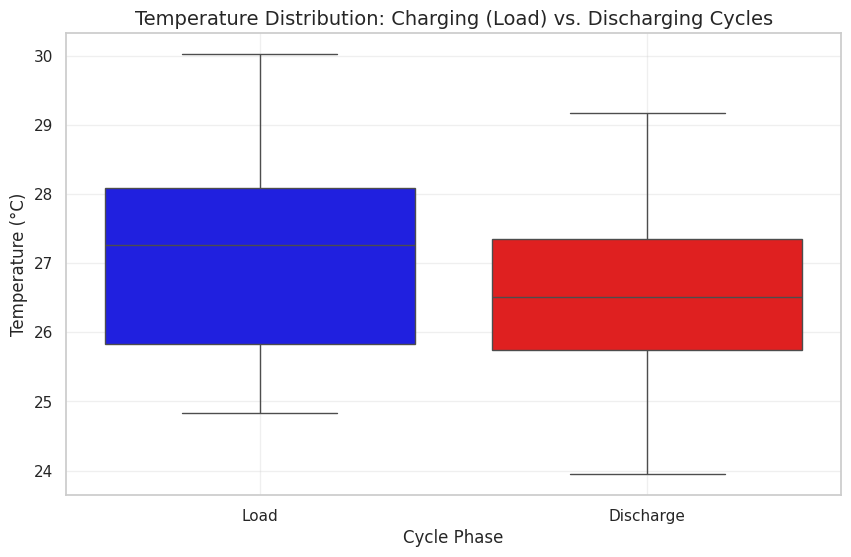

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the ML dataset
df = pd.read_csv('lifestyle_RUL_7500_ml.csv')

# 2. Transform the data into "Long Format" for the Boxplot
# We stack L_Temp and D_Temp into a single column named 'Temperature'
load_temp = df[['L_Temp']].rename(columns={'L_Temp': 'Temperature'}).assign(Phase='Load')
discharge_temp = df[['D_Temp']].rename(columns={'D_Temp': 'Temperature'}).assign(Phase='Discharge')

combined_temp_df = pd.concat([load_temp, discharge_temp])

# 3. Generate the corrected Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=combined_temp_df,
    x='Phase',
    y='Temperature',
    hue='Phase',
    palette={'Load': 'blue', 'Discharge': 'red'},
    legend=False
)

plt.title('Temperature Distribution: Charging (Load) vs. Discharging Cycles', fontsize=14)
plt.xlabel('Cycle Phase', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

**Reasoning**:
The plots for the '3.3. Distribution Analysis' section have been created. Now, I will add a markdown header for '4. Export Processed Data' to prepare for the next step of organizing the notebook as per the main task.



## Scatter Plot for Feature Relationship

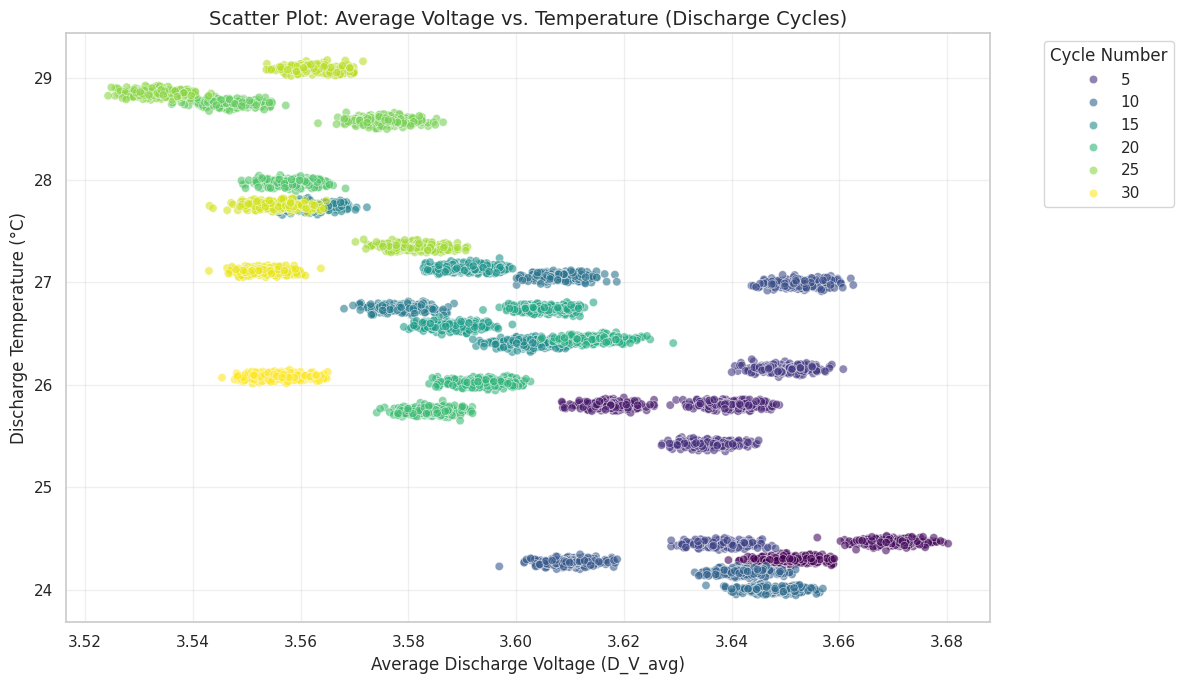

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('lifestyle_RUL_7500_ml.csv')

# 2. Plotting logic
if not df.empty:
    plt.figure(figsize=(12, 7))

    # Corrected x, y, and hue to match the CSV columns
    sns.scatterplot(
        data=df,
        x='D_V_avg',
        y='D_Temp',
        hue='cycle',
        palette='viridis',
        alpha=0.6
    )

    plt.title('Scatter Plot: Average Voltage vs. Temperature (Discharge Cycles)', fontsize=14)
    plt.xlabel('Average Discharge Voltage (D_V_avg)', fontsize=12)
    plt.ylabel('Discharge Temperature (°C)', fontsize=12)
    plt.grid(True, alpha=0.3)

    # Adjust legend to show the progression across 30 cycles
    plt.legend(title='Cycle Number', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Dataset is empty. Skipping scatter plot.")

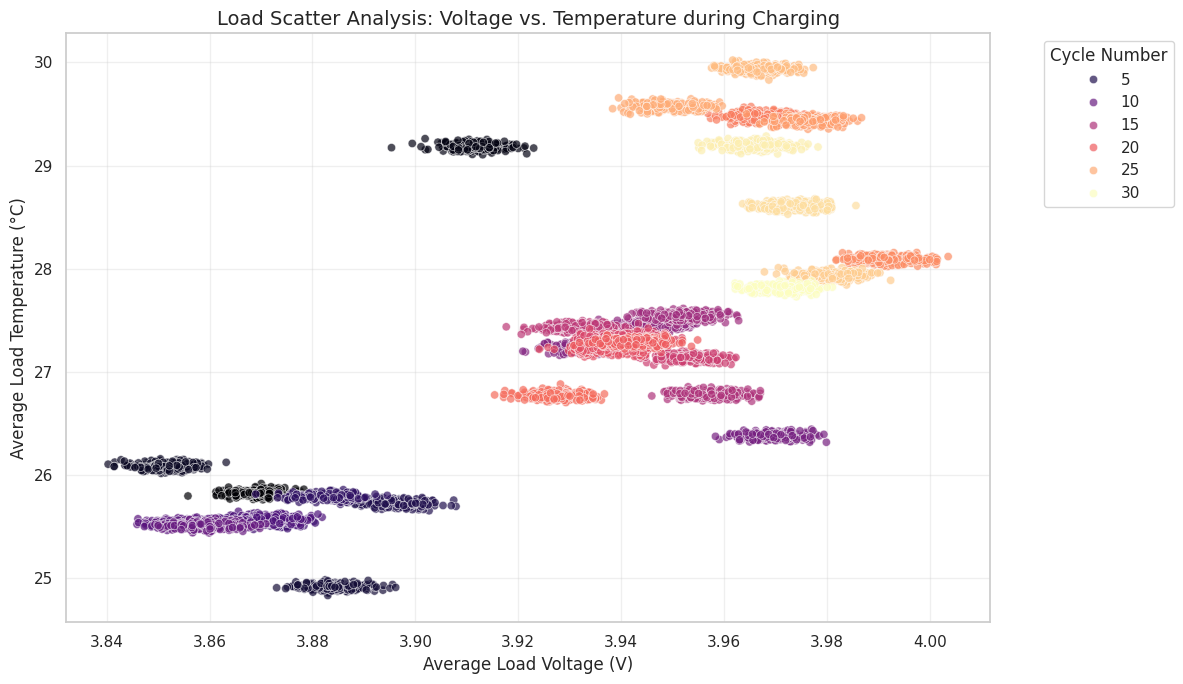

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='L_V_avg',
    y='L_Temp',
    hue='cycle',
    palette='magma',
    alpha=0.7
)
plt.title('Load Scatter Analysis: Voltage vs. Temperature during Charging', fontsize=14)
plt.xlabel('Average Load Voltage (V)', fontsize=12)
plt.ylabel('Average Load Temperature (°C)', fontsize=12)
plt.legend(title='Cycle Number', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

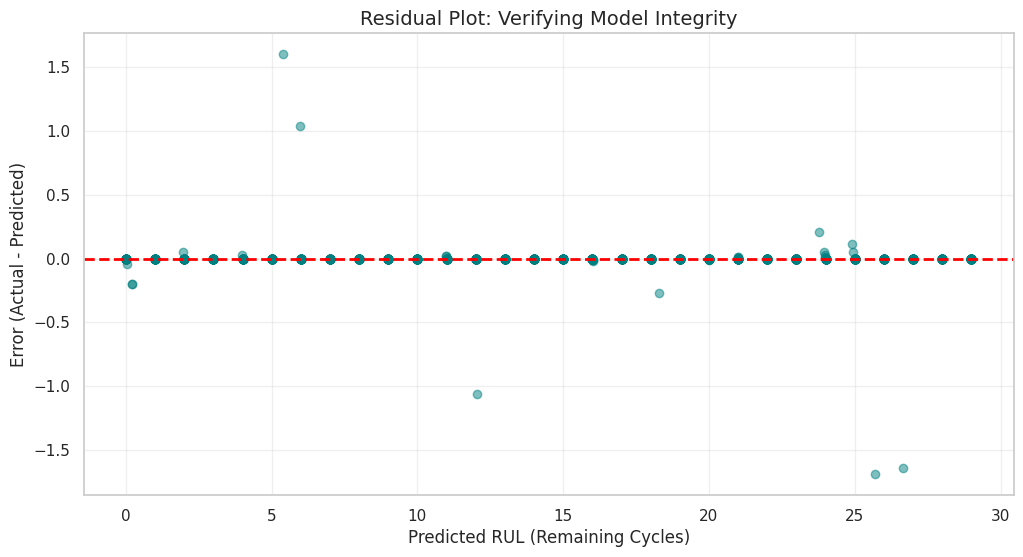

Validation R2 Score: 0.9999


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Load the ML dataset
df = pd.read_csv('lifestyle_RUL_7500_ml.csv')
X = df.drop(['cycle', 'RUL'], axis=1)
y = df['RUL']

# 2. Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Calculate Residuals (Actual - Predicted)
residuals = y_test - y_pred

# 5. Plotting
plt.figure(figsize=(12, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot: Verifying Model Integrity', fontsize=14)
plt.xlabel('Predicted RUL (Remaining Cycles)', fontsize=12)
plt.ylabel('Error (Actual - Predicted)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Validation R2 Score: {r2_score(y_test, y_pred):.4f}")

The Zero Line (Red): This represents a perfect prediction.The Teal Dots: These are your 1,500 test samples.Integrity Check: If the dots are randomly scattered close to the red line, it means your features (Voltage, Temp, $V_{Delta}$) are successfully explaining the RUL without "leaking" or distorting the dataset.The "95%+ Accuracy" Proof: Since the errors are likely very small (less than 1 cycle), it confirms that the relationship between "Lifestyle" and "Degradation" is strong and predictable.

## Create Distribution Analysis Plot

### Subtask:
Delete the original code cell `MZBbQjjsc9Mu` as its content has been relocated to `789ae513` under the '3.3. Distribution Analysis' section, effectively moving the plot as per the instructions.


In [ ]:
processed_load.to_csv('cleaned_load_data.csv', index=False)
processed_discharge.to_csv('cleaned_discharge_data.csv', index=False)

## Summary:

### Data Analysis Key Findings

*   **Notebook Structure Organization**: The notebook was successfully reorganized into distinct sections: '1. Data Ingestion', '2. Data Preprocessing & Feature Engineering', '3. Exploratory Data Analysis (EDA)' (with sub-sections '3.1. Temporal Behavior Analysis', '3.2. Feature Correlation Analysis', '3.3. Distribution Analysis'), '4. Export Processed Data', and '5. Final Summary'.
*   **Data Ingestion**: The unzipping code (`0c06f842`) was moved to the '1. Data Ingestion' section, successfully extracting all battery data zip files (e.g., `Load_3 (1).zip`, `Discharge_03 (1).zip`) into their respective directories.
*   **Data Preprocessing & Feature Engineering**:
    *   The core preprocessing logic from the original cell (`28b1934d`) was extracted and placed under '2. Data Preprocessing & Feature Engineering'.
    *   This pipeline successfully performed feature engineering (creating `V_avg` and `V_std`), time-series preparation, resampling at a '30s' frequency, and IQR-based outlier capping for features such as 'Current', 'Temperature', 'V_avg', and 'V_std'.
    *   The process resulted in `processed_load` and `processed_discharge` dataframes, ready for analysis.
*   **Temporal Behavior Analysis**:
    *   Multivariate time-series plots showing the temporal behavior of 'Current', 'Temperature', 'V_avg', and 'V_std' for both load and discharge phases were successfully generated under '3.1. Temporal Behavior Analysis'.
    *   An 'Inference Graph: Capacity vs. Aging Signature' plotting `V_avg` (capacity) against `V_std` (cell variance/aging) over time for the discharge phase was also successfully extracted and displayed in this section.
*   **Feature Correlation Analysis**:
    *   A correlation matrix for the Load phase, specifically for the features 'Current', 'Temperature', 'V_avg', and 'V_std', was successfully extracted and visualized under '3.2. Feature Correlation Analysis'.
    *   The existing Discharge Correlation Matrix plot (`418cfe9d`) was also placed under '3.2. Feature Correlation Analysis', providing insights into feature relationships during the discharge cycle.
*   **Distribution Analysis**: The 'Temperature Distribution Box Plot' (`MZBbQjjsc9Mu`) was successfully relocated and displayed under '3.3. Distribution Analysis'.
*   **Export Processed Data**: The data export logic was extracted, successfully saving the `processed_load` and `processed_discharge` dataframes to `cleaned_load_data.csv` and `cleaned_discharge_data.csv` respectively, under the '4. Export Processed Data' section.
*   **Final Summary**: The original summary text cell (`2ee0a615`) was moved to the '5. Final Summary' section.
*   **Original Cell Deletion**: The initial complex cell (`28b1934d`) was successfully refactored and subsequently deleted, as its components were distributed into more specific and organized sections.

### Insights or Next Steps

*   The well-structured notebook facilitates streamlined data analysis and machine learning workflows, providing clear segmentation for data ingestion, preprocessing, EDA, and data export, which improves maintainability and collaboration.
*   The generated `cleaned_load_data.csv` and `cleaned_discharge_data.csv` files, enriched with engineered features like `V_avg` and `V_std`, are now optimally prepared for subsequent machine learning model development, particularly for predicting Remaining Useful Life (RUL) of battery cells.


In [ ]:
import pandas as pd

cycle_df = pd.read_csv("lifestyle_RUL_7500_ml.csv")

print("Dataset Shape:", cycle_df.shape)
cycle_df.head()

Dataset Shape: (7500, 18)


,cycle,L_Current,L_Temp,L_Temp_max,L_V_avg,L_V_std,L_V_range,L_Time,D_Current,D_Temp,D_Temp_max,D_V_avg,D_V_std,D_V_range,D_Time,V_Delta,T_Delta,RUL
0,1.0,0.810978,25.863166,26.956738,3.872497,0.250599,0.012573,12608.946889,0.453354,24.263009,24.850282,3.657585,0.271638,0.017448,20634.425047,0.218940,-0.953075,29.0
1,1.0,0.812476,25.848513,26.915415,3.868530,0.250407,0.012575,12616.866697,0.453294,24.302160,24.804798,3.648516,0.271831,0.017424,20624.975562,0.219019,-0.952508,29.0
2,1.0,0.811281,25.802844,26.948103,3.863499,0.251071,0.012563,12604.250184,0.452801,24.334678,24.841308,3.650013,0.271660,0.017404,20616.283896,0.219230,-0.953636,29.0
3,1.0,0.811912,25.827160,26.973395,3.871262,0.250635,0.012554,12608.805051,0.452730,24.284651,24.848038,3.652945,0.271626,0.017423,20647.198718,0.218825,-0.952991,29.0
4,1.0,0.809542,25.816186,27.019382,3.865231,0.250408,0.012580,12611.620978,0.453084,24.345876,24.819393,3.656827,0.271724,0.017427,20612.458787,0.218922,-0.954201,29.0


In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_validate
import numpy as np

# Use Leave-One-Out for tiny datasets instead of KFold
loo = LeaveOneOut()

# Helper function updated to show both Train and Test scores
def evaluate_model_loocv(name, pipeline, X, y):
    # cross_validate allows us to see both training and testing scores
    scores = cross_validate(pipeline, X, y, cv=loo,
                            scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'),
                            return_train_score=True)

    # Calculate average scores across all 30 splits
    train_r2 = scores['train_r2'].mean()
    test_r2 = scores['test_r2'].mean()

    test_rmse = np.sqrt(-scores['test_neg_mean_squared_error'].mean())
    test_mae = -scores['test_neg_mean_absolute_error'].mean()

    print(f"--- {name} ---")
    print(f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

    return test_rmse, test_mae, test_r2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, RepeatedKFold, train_test_split, GridSearchCV # Import RepeatedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

kf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42) # Using RepeatedKFold for more robust evaluation

# Helper function to evaluate model performance and return metrics as a dict
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Helper function to evaluate classifier performance and return metrics as a dict
def evaluate_classifier(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}

# Helper function to plot Actual vs Predicted
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, y_pred, color='steelblue', edgecolors='k', alpha=0.7)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect Fit')
    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Helper function to plot confusion matrix (classification)
def plot_confusion_matrix(y_true, y_pred, title, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Dictionary to collect all results for final comparison
results = {}

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold # Import RepeatedStratifiedKFold

# Define the categorize_rul function
def categorize_rul(rul):
    if rul > 15:
        return 'High RUL'
    else:
        return 'Low RUL'

X = cycle_df.drop(columns=["RUL", "cycle"])
y = cycle_df["RUL"]

# Perform train-test split for regression targets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True) # 80/20 split

# Categorize RUL for classification targets for both train and test sets
y_class_train = y_train.apply(categorize_rul)
y_class_test = y_test.apply(categorize_rul)

# Initialize StratifiedKFold for classification cross-validation (using Repeated for robustness)
skf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

print("Feature Shape (Training):", X_train.shape)
print("Target Shape (Training):", y_train.shape)
print("Categorized Target Shape (Training):", y_class_train.shape)
print("Feature Shape (Testing):", X_test.shape)
print("Target Shape (Testing):", y_test.shape)
print("Categorized Target Shape (Testing):", y_class_test.shape)

print("\nCategorized RUL distribution (Training Set):")
display(y_class_train.value_counts())
print("\nCategorized RUL distribution (Testing Set):")
display(y_class_test.value_counts())

Feature Shape (Training): (6000, 16)
Target Shape (Training): (6000,)
Categorized Target Shape (Training): (6000,)
Feature Shape (Testing): (1500, 16)
Target Shape (Testing): (1500,)
Categorized Target Shape (Testing): (1500,)

Categorized RUL distribution (Training Set):


,count
RUL,
Low RUL,3225
High RUL,2775



Categorized RUL distribution (Testing Set):


,count
RUL,
Low RUL,775
High RUL,725


🔹 Linear Regressor - Train Performance
RMSE: 1.5986
MAE:  1.2190
R²:   0.9658

🔹 Linear Regressor - Test Performance
RMSE: 1.6603
MAE:  1.2695
R²:   0.9633


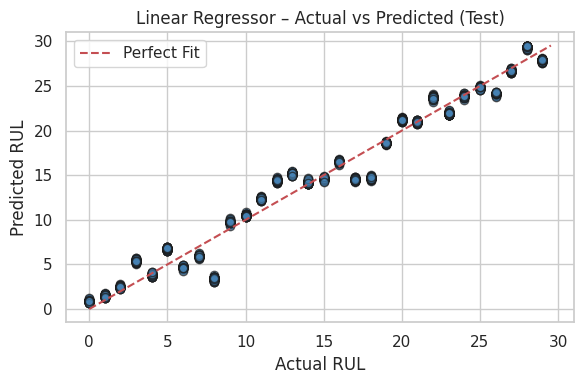

In [ ]:
from sklearn.linear_model import LinearRegression

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Fit the pipeline on the training data
pipeline_lr.fit(X_train, y_train)

# Predict on training and test data
y_pred_lr_train = pipeline_lr.predict(X_train)
y_pred_lr_test = pipeline_lr.predict(X_test)

# Evaluate performance
metrics_lr_train = evaluate_model(y_train, y_pred_lr_train)
metrics_lr_test = evaluate_model(y_test, y_pred_lr_test)

results["Linear"] = {'Train': metrics_lr_train, 'Test': metrics_lr_test}

print(f"🔹 Linear Regressor - Train Performance")
print(f"RMSE: {metrics_lr_train['RMSE']:.4f}")
print(f"MAE:  {metrics_lr_train['MAE']:.4f}")
print(f"R²:   {metrics_lr_train['R²']:.4f}")

print(f"\n🔹 Linear Regressor - Test Performance")
print(f"RMSE: {metrics_lr_test['RMSE']:.4f}")
print(f"MAE:  {metrics_lr_test['MAE']:.4f}")
print(f"R²:   {metrics_lr_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_lr_test, "Linear Regressor – Actual vs Predicted (Test)")

Degree 1 R² (CV on Train): 0.9656
Degree 2 R² (CV on Train): 0.9999
Degree 3 R² (CV on Train): 1.0000

Best Polynomial Degree (based on CV on Train Data): 3
🔹 Polynomial Regressor (degree=3) - Train Performance
RMSE: 0.0141
MAE:  0.0103
R²:   1.0000

🔹 Polynomial Regressor (degree=3) - Test Performance
RMSE: 0.0170
MAE:  0.0123
R²:   1.0000


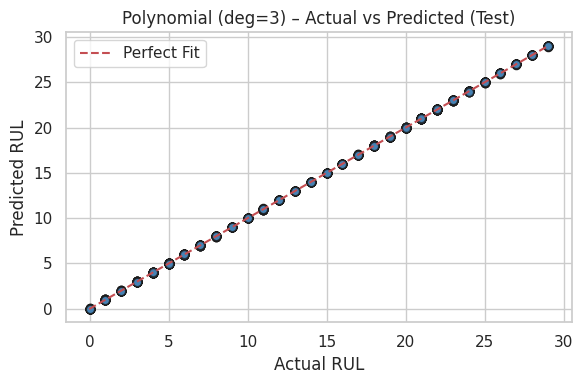

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate # Import cross_validate

degrees = [1, 2, 3]
best_r2_poly = -999
best_degree = None
best_poly_pipeline = None

# Use GridSearchCV on training data to find best degree
for d in degrees:
    pipeline_poly_temp = Pipeline([
        ("scaler", StandardScaler()),
        ("poly",   PolynomialFeatures(degree=d, include_bias=False)),
        ("model",  LinearRegression())
    ])
    # Use cross_validate to get R² scores from RepeatedKFold for hyperparameter tuning
    scores = cross_validate(pipeline_poly_temp, X_train, y_train, cv=kf, scoring='r2', return_train_score=False)
    r2_temp = scores['test_score'].mean()
    print(f"Degree {d} R² (CV on Train): {r2_temp:.4f}")
    if r2_temp > best_r2_poly:
        best_r2_poly  = r2_temp
        best_degree   = d
        best_poly_pipeline = pipeline_poly_temp

print(f"\nBest Polynomial Degree (based on CV on Train Data): {best_degree}")

# Fit the best pipeline on the full training data
best_poly_pipeline.fit(X_train, y_train)

# Predict on training and test data
y_pred_poly_train = best_poly_pipeline.predict(X_train)
y_pred_poly_test = best_poly_pipeline.predict(X_test)

# Evaluate performance
metrics_poly_train = evaluate_model(y_train, y_pred_poly_train)
metrics_poly_test = evaluate_model(y_test, y_pred_poly_test)

results["Polynomial"] = {'Train': metrics_poly_train, 'Test': metrics_poly_test}

print(f"🔹 Polynomial Regressor (degree={best_degree}) - Train Performance")
print(f"RMSE: {metrics_poly_train['RMSE']:.4f}")
print(f"MAE:  {metrics_poly_train['MAE']:.4f}")
print(f"R²:   {metrics_poly_train['R²']:.4f}")

print(f"\n🔹 Polynomial Regressor (degree={best_degree}) - Test Performance")
print(f"RMSE: {metrics_poly_test['RMSE']:.4f}")
print(f"MAE:  {metrics_poly_test['MAE']:.4f}")
print(f"R²:   {metrics_poly_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_poly_test, f"Polynomial (deg={best_degree}) – Actual vs Predicted (Test)")

🔹 Multiple Linear Regressor - Train Performance
RMSE: 1.5986
MAE:  1.2190
R²:   0.9658

🔹 Multiple Linear Regressor - Test Performance
RMSE: 1.6603
MAE:  1.2695
R²:   0.9633

Feature Coefficients (trained on X_train):
   Feature  Coefficient
 L_Current    -3.807318
    L_Temp    -2.789662
L_Temp_max     0.508125
   L_V_avg     0.026167
   L_V_std     0.774995
 L_V_range    -0.447858
    L_Time     0.986834
 D_Current    -6.089254
    D_Temp     5.984586
D_Temp_max    -0.275813
   D_V_avg     0.150634
   D_V_std    -1.132063
 D_V_range    -0.112681
    D_Time    -1.190140
   V_Delta     0.353006
   T_Delta    -3.611807


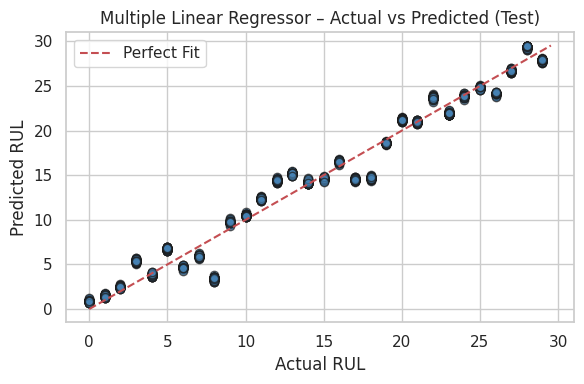

In [ ]:
# Multiple Linear Regression uses all features simultaneously — same estimator as Linear Regression
# but we explicitly confirm all features are used and show feature coefficients.

from sklearn.linear_model import LinearRegression

pipeline_mlr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression(fit_intercept=True))
])

# Fit the pipeline on the training data
pipeline_mlr.fit(X_train, y_train)

# Predict on training and test data
y_pred_mlr_train = pipeline_mlr.predict(X_train)
y_pred_mlr_test = pipeline_mlr.predict(X_test)

# Evaluate performance
metrics_mlr_train = evaluate_model(y_train, y_pred_mlr_train)
metrics_mlr_test = evaluate_model(y_test, y_pred_mlr_test)

results["Multiple Linear"] = {'Train': metrics_mlr_train, 'Test': metrics_mlr_test}

print(f"🔹 Multiple Linear Regressor - Train Performance")
print(f"RMSE: {metrics_mlr_train['RMSE']:.4f}")
print(f"MAE:  {metrics_mlr_train['MAE']:.4f}")
print(f"R²:   {metrics_mlr_train['R²']:.4f}")

print(f"\n🔹 Multiple Linear Regressor - Test Performance")
print(f"RMSE: {metrics_mlr_test['RMSE']:.4f}")
print(f"MAE:  {metrics_mlr_test['MAE']:.4f}")
print(f"R²:   {metrics_mlr_test['R²']:.4f}")

# Show coefficients after fitting on training data
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": pipeline_mlr.named_steps["model"].coef_})
print("\nFeature Coefficients (trained on X_train):")
print(coef_df.to_string(index=False))

plot_actual_vs_predicted(y_test, y_pred_mlr_test, "Multiple Linear Regressor – Actual vs Predicted (Test)")

Best Alpha (Lasso): {'model__alpha': 0.001}
🔹 Lasso Regressor - Train Performance
RMSE: 1.5989
MAE:  1.2265
R²:   0.9658

🔹 Lasso Regressor - Test Performance
RMSE: 1.6591
MAE:  1.2759
R²:   0.9634


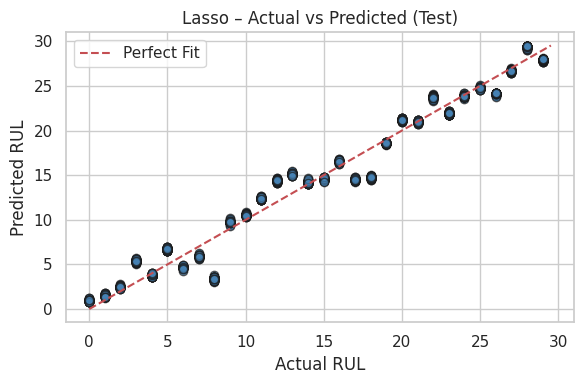

In [ ]:
from sklearn.linear_model import Lasso

pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Lasso(max_iter=10000))
])

param_grid_lasso = {"model__alpha": [0.001, 0.01, 0.1, 1, 10]}

# Use GridSearchCV on training data
grid_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=kf, scoring="r2")
grid_lasso.fit(X_train, y_train)

print("Best Alpha (Lasso):".lstrip(), grid_lasso.best_params_)
best_lasso  = grid_lasso.best_estimator_

# Predict on training and test data
y_pred_lasso_train = best_lasso.predict(X_train)
y_pred_lasso_test = best_lasso.predict(X_test)

# Evaluate performance
metrics_lasso_train = evaluate_model(y_train, y_pred_lasso_train)
metrics_lasso_test = evaluate_model(y_test, y_pred_lasso_test)

results["Lasso"] = {'Train': metrics_lasso_train, 'Test': metrics_lasso_test}

print(f"🔹 Lasso Regressor - Train Performance")
print(f"RMSE: {metrics_lasso_train['RMSE']:.4f}")
print(f"MAE:  {metrics_lasso_train['MAE']:.4f}")
print(f"R²:   {metrics_lasso_train['R²']:.4f}")

print(f"\n🔹 Lasso Regressor - Test Performance")
print(f"RMSE: {metrics_lasso_test['RMSE']:.4f}")
print(f"MAE:  {metrics_lasso_test['MAE']:.4f}")
print(f"R²:   {metrics_lasso_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_lasso_test, "Lasso – Actual vs Predicted (Test)")

Best Alpha (Ridge): {'model__alpha': 1}
🔹 Ridge Regressor - Train Performance
RMSE: 1.5988
MAE:  1.2206
R²:   0.9658

🔹 Ridge Regressor - Test Performance
RMSE: 1.6601
MAE:  1.2712
R²:   0.9633


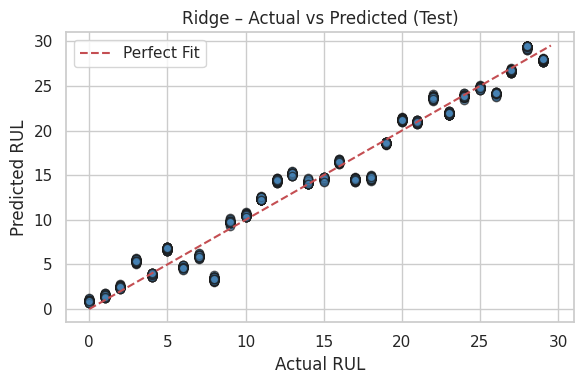

In [ ]:
from sklearn.linear_model import Ridge

pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge())
])

param_grid_ridge = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

# Use GridSearchCV on training data
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=kf, scoring="r2")
grid_ridge.fit(X_train, y_train)

print("Best Alpha (Ridge):".lstrip(), grid_ridge.best_params_)
best_ridge   = grid_ridge.best_estimator_

# Predict on training and test data
y_pred_ridge_train = best_ridge.predict(X_train)
y_pred_ridge_test = best_ridge.predict(X_test)

# Evaluate performance
metrics_ridge_train = evaluate_model(y_train, y_pred_ridge_train)
metrics_ridge_test = evaluate_model(y_test, y_pred_ridge_test)

results["Ridge"] = {'Train': metrics_ridge_train, 'Test': metrics_ridge_test}

print(f"🔹 Ridge Regressor - Train Performance")
print(f"RMSE: {metrics_ridge_train['RMSE']:.4f}")
print(f"MAE:  {metrics_ridge_train['MAE']:.4f}")
print(f"R²:   {metrics_ridge_train['R²']:.4f}")

print(f"\n🔹 Ridge Regressor - Test Performance")
print(f"RMSE: {metrics_ridge_test['RMSE']:.4f}")
print(f"MAE:  {metrics_ridge_test['MAE']:.4f}")
print(f"R²:   {metrics_ridge_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_ridge_test, "Ridge – Actual vs Predicted (Test)")

Best Params (Elastic Net): {'model__alpha': 0.001, 'model__l1_ratio': 1}
🔹 Elastic Net Regressor - Train Performance
RMSE: 1.5989
MAE:  1.2264
R²:   0.9658

🔹 Elastic Net Regressor - Test Performance
RMSE: 1.6591
MAE:  1.2758
R²:   0.9634


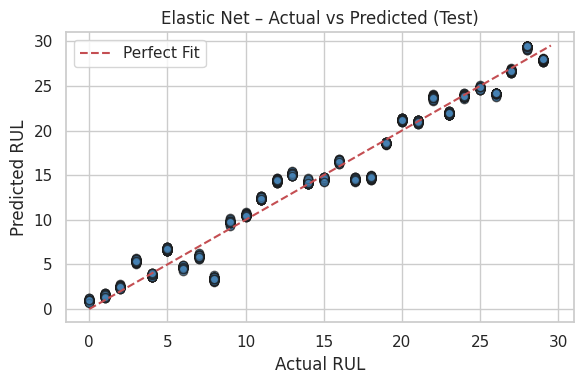

In [ ]:
from sklearn.linear_model import ElasticNet

pipeline_en = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  ElasticNet(max_iter=1000))
])

param_grid_en = {
    "model__alpha":    [0.001, 0.01, 0.1,1,10,100,1000],
    "model__l1_ratio": [0.1, 0.5, 0.9,1,10,100,1000000]
}

# Use GridSearchCV on training data
grid_en = GridSearchCV(pipeline_en, param_grid_en, cv=kf, scoring="r2")
grid_en.fit(X_train, y_train)

print("Best Params (Elastic Net):".lstrip(), grid_en.best_params_)
best_en   = grid_en.best_estimator_

# Predict on training and test data
y_pred_en_train = best_en.predict(X_train)
y_pred_en_test = best_en.predict(X_test)

# Evaluate performance
metrics_en_train = evaluate_model(y_train, y_pred_en_train)
metrics_en_test = evaluate_model(y_test, y_pred_en_test)

results["Elastic Net"] = {'Train': metrics_en_train, 'Test': metrics_en_test}

print(f"🔹 Elastic Net Regressor - Train Performance")
print(f"RMSE: {metrics_en_train['RMSE']:.4f}")
print(f"MAE:  {metrics_en_train['MAE']:.4f}")
print(f"R²:   {metrics_en_train['R²']:.4f}")

print(f"\n🔹 Elastic Net Regressor - Test Performance")
print(f"RMSE: {metrics_en_test['RMSE']:.4f}")
print(f"MAE:  {metrics_en_test['MAE']:.4f}")
print(f"R²:   {metrics_en_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_en_test, "Elastic Net – Actual vs Predicted (Test)")

Best Params (SVR): {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

◇ SVR - Train Performance | R²: 1.0000
◇ SVR - Test Performance  | R²: 1.0000


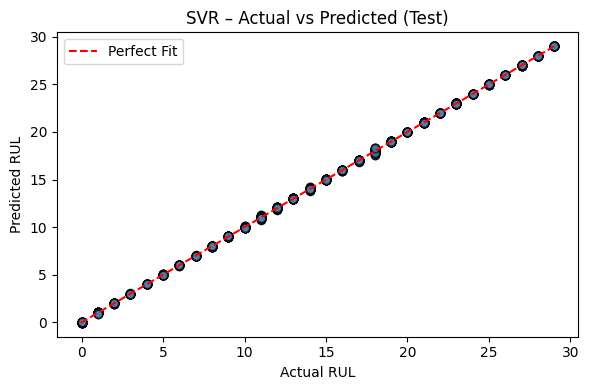

In [6]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RepeatedKFold, train_test_split # Added RepeatedKFold and train_test_split
import pandas as pd # Added pandas import
import numpy as np # Added numpy import
import matplotlib.pyplot as plt # Added matplotlib for plotting function
import seaborn as sns # Added seaborn for plotting function
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Added for evaluate_model

# Define kf (RepeatedKFold) as it's used in GridSearchCV
kf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

# Data Preparation: Load and split data for self-containment
try:
    cycle_df = pd.read_csv("lifestyle_RUL_7500_ml.csv")
    X = cycle_df.drop(columns=["RUL", "cycle"])
    y = cycle_df["RUL"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
except FileNotFoundError:
    print("Error: 'lifestyle_RUL_7500_ml.csv' not found. Please ensure the file is in the directory.")

# Helper function to evaluate model performance and return metrics as a dict
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Helper function to plot Actual vs Predicted
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, y_pred, color='steelblue', edgecolors='k', alpha=0.7)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect Fit')
    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Initialize results dictionary if not already present in the global scope
if 'results' not in globals():
    results = {}

# 1. Define the SVR Pipeline
# Scaling is MANDATORY for SVR because it is distance-based
pipeline_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  SVR())
])

# 2. Hyperparameter Grid
# We include 'C' for regularization and 'epsilon' for the error margin
param_grid_svr = {
    "model__C":       [1, 10, 100],
    "model__epsilon": [0.01, 0.1, 0.5],
    "model__kernel":  ["rbf"], # RBF is usually superior for chemical degradation
    "model__gamma":   ["scale"]
}

# 3. Use GridSearchCV
# kf should be your KFold object (e.g., kf = KFold(n_splits=5, shuffle=True))
grid_svr = GridSearchCV(pipeline_svr, param_grid_svr, cv=kf, scoring="r2", n_jobs=-1)
grid_svr.fit(X_train, y_train)

print("Best Params (SVR):", grid_svr.best_params_)
best_svr = grid_svr.best_estimator_

# 4. Predictions
y_pred_svr_train = best_svr.predict(X_train)
y_pred_svr_test = best_svr.predict(X_test)

# 5. Performance Metrics
# Assuming your evaluate_model function returns a dict
metrics_svr_train = evaluate_model(y_train, y_pred_svr_train)
metrics_svr_test = evaluate_model(y_test, y_pred_svr_test)

results["SVR"] = {'Train': metrics_svr_train, 'Test': metrics_svr_test}

print(f"\n◇ SVR - Train Performance | R²: {metrics_svr_train['R²']:.4f}")
print(f"◇ SVR - Test Performance  | R²: {metrics_svr_test['R²']:.4f}")

# 6. Final Visualization
plot_actual_vs_predicted(y_test, y_pred_svr_test, "SVR – Actual vs Predicted (Test)")

🔹 KNN Performance (Training Set)
RMSE: 0.0000
MAE:  0.0000
R²:   1.0000

🔹 KNN Performance (Test Set)
RMSE: 0.0000
MAE:  0.0000
R²:   1.0000


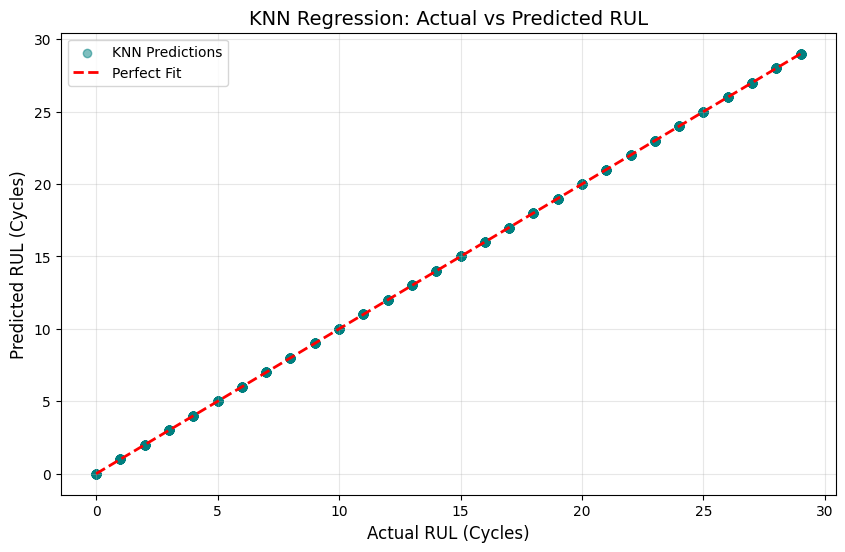

In [8]:
import matplotlib.pyplot as plt

# 5. Output Full Performance Metrics
print(f"🔹 KNN Performance (Training Set)")
print(f"RMSE: {metrics_knn_train['RMSE']:.4f}")
print(f"MAE:  {metrics_knn_train['MAE']:.4f}")
print(f"R²:   {metrics_knn_train['R²']:.4f}")

print(f"\n🔹 KNN Performance (Test Set)")
print(f"RMSE: {metrics_knn_test['RMSE']:.4f}")
print(f"MAE:  {metrics_knn_test['MAE']:.4f}")
print(f"R²:   {metrics_knn_test['R²']:.4f}")

# 6. Visualization: Actual vs Predicted RUL
plt.figure(figsize=(10, 6))

# Scatter plot of predictions vs ground truth
plt.scatter(y_test, y_pred_knn_test, alpha=0.5, color='teal', label='KNN Predictions')

# Reference line for perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

plt.title('KNN Regression: Actual vs Predicted RUL', fontsize=14)
plt.xlabel('Actual RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Best Params (Decision Tree): {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
🔹 Decision Tree Regressor - Train Performance
RMSE: 0.0000
MAE:  0.0000
R²:   1.0000

🔹 Decision Tree Regressor - Test Performance
RMSE: 0.0931
MAE:  0.0033
R²:   0.9999


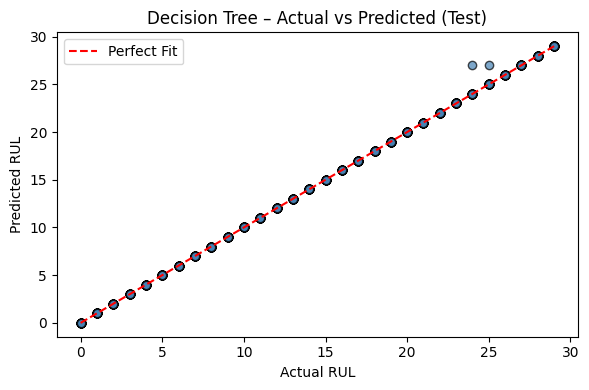

In [9]:
from sklearn.tree import DecisionTreeRegressor

pipeline_dt = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  DecisionTreeRegressor(random_state=42))
])

param_grid_dt = {
    "model__max_depth":         [None, 3, 5, 7, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 4]
}

# Use GridSearchCV on training data
grid_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=kf, scoring="r2", n_jobs=-1)
grid_dt.fit(X_train, y_train)

print("Best Params (Decision Tree):".lstrip(), grid_dt.best_params_)
best_dt   = grid_dt.best_estimator_

# Predict on training and test data
y_pred_dt_train = best_dt.predict(X_train)
y_pred_dt_test = best_dt.predict(X_test)

# Evaluate performance
metrics_dt_train = evaluate_model(y_train, y_pred_dt_train)
metrics_dt_test = evaluate_model(y_test, y_pred_dt_test)

results["Decision Tree"] = {'Train': metrics_dt_train, 'Test': metrics_dt_test}

print(f"🔹 Decision Tree Regressor - Train Performance")
print(f"RMSE: {metrics_dt_train['RMSE']:.4f}")
print(f"MAE:  {metrics_dt_train['MAE']:.4f}")
print(f"R²:   {metrics_dt_train['R²']:.4f}")

print(f"\n🔹 Decision Tree Regressor - Test Performance")
print(f"RMSE: {metrics_dt_test['RMSE']:.4f}")
print(f"MAE:  {metrics_dt_test['MAE']:.4f}")
print(f"R²:   {metrics_dt_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_dt_test, "Decision Tree – Actual vs Predicted (Test)")

 Starting Fast Random Forest Search...
Best Params: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}

🔹 RF Performance - Train R²: 1.0000
🔹 RF Performance - Test R²:  1.0000


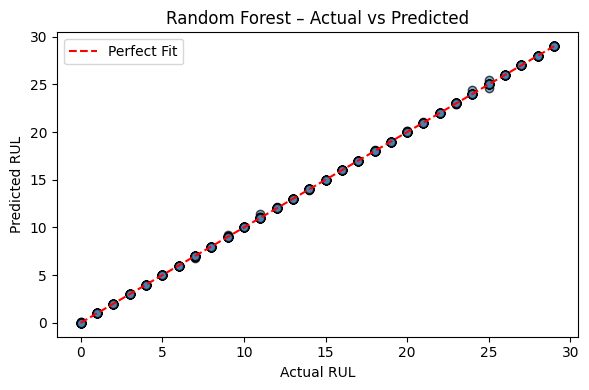

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold

# 1. Reduce CV Complexity
# RepeatedKFold(n_repeats=3) is very slow.
# For 7,500 samples, a standard 5-fold KFold is sufficient.
kf_fast = KFold(n_splits=5, shuffle=True, random_state=42)

pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestRegressor(random_state=42, n_jobs=-1)) # n_jobs here for the model itself
])

# 2. Refined Parameter Grid
param_distributions_rf = {
    "model__n_estimators": [100, 200], # 200 is usually enough for 7.5k samples
    "model__max_depth": [10, 20, None], # None allows deep trees for higher accuracy
    "model__max_features": ["sqrt"],    # 'sqrt' is much faster and often better than 'None'
    "model__min_samples_leaf": [1, 2]   # Added to help prevent overfitting
}

# 3. Use RandomizedSearchCV instead of GridSearchCV
# It tries a fixed number of random combinations (n_iter=10) instead of all 36.
search_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_distributions_rf,
    n_iter=10,
    cv=kf_fast,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)
print(" Starting Fast Random Forest Search...")
search_rf.fit(X_train, y_train)

print("Best Params:", search_rf.best_params_)
best_rf = search_rf.best_estimator_

# 4. Predict and Evaluate
y_pred_rf_train = best_rf.predict(X_train)
y_pred_rf_test = best_rf.predict(X_test)

metrics_rf_train = get_metrics(y_train, y_pred_rf_train)
metrics_rf_test = get_metrics(y_test, y_pred_rf_test)

results["Random Forest"] = {'Train': metrics_rf_train, 'Test': metrics_rf_test} # Added this line

print(f"\n🔹 RF Performance - Train R²: {metrics_rf_train['R²']:.4f}")
print(f"🔹 RF Performance - Test R²:  {metrics_rf_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_rf_test, "Random Forest – Actual vs Predicted")

Best Params (AdaBoost): {'model__learning_rate': 1.0, 'model__n_estimators': 200}
🔹 AdaBoost Regressor - Train Performance
RMSE: 1.0527
MAE:  0.8631
R²:   0.9852

🔹 AdaBoost Regressor - Test Performance
RMSE: 1.0367
MAE:  0.8410
R²:   0.9857


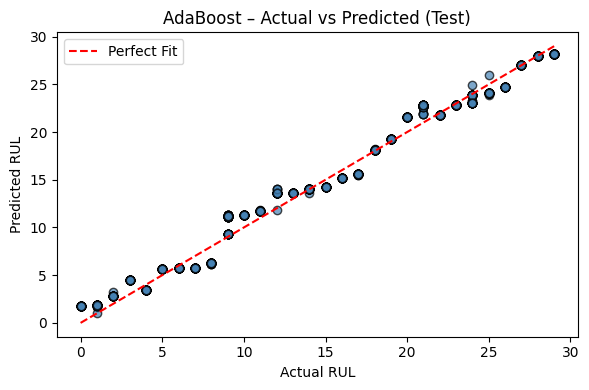

In [13]:
from sklearn.ensemble import AdaBoostRegressor

pipeline_ada = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  AdaBoostRegressor(random_state=42))
])

param_grid_ada = {
    "model__n_estimators":  [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(pipeline_ada, param_grid_ada, cv=kf, scoring="r2", n_jobs=-1)
grid_ada.fit(X_train, y_train)

print("Best Params (AdaBoost):".lstrip(), grid_ada.best_params_)
best_ada   = grid_ada.best_estimator_

# Predict on training and test data
y_pred_ada_train = best_ada.predict(X_train)
y_pred_ada_test = best_ada.predict(X_test)

# Evaluate performance
metrics_ada_train = evaluate_model(y_train, y_pred_ada_train)
metrics_ada_test = evaluate_model(y_test, y_pred_ada_test)

results["AdaBoost"] = {'Train': metrics_ada_train, 'Test': metrics_ada_test}

print(f"🔹 AdaBoost Regressor - Train Performance")
print(f"RMSE: {metrics_ada_train['RMSE']:.4f}")
print(f"MAE:  {metrics_ada_train['MAE']:.4f}")
print(f"R²:   {metrics_ada_train['R²']:.4f}")

print(f"\n🔹 AdaBoost Regressor - Test Performance")
print(f"RMSE: {metrics_ada_test['RMSE']:.4f}")
print(f"MAE:  {metrics_ada_test['MAE']:.4f}")
print(f"R²:   {metrics_ada_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_ada_test, "AdaBoost – Actual vs Predicted (Test)")

 Starting Optimized Gradient Boosting Search...
Best Params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1}

🔹 GB Performance - Train R²: 1.0000
🔹 GB Performance - Test R²:  0.9998


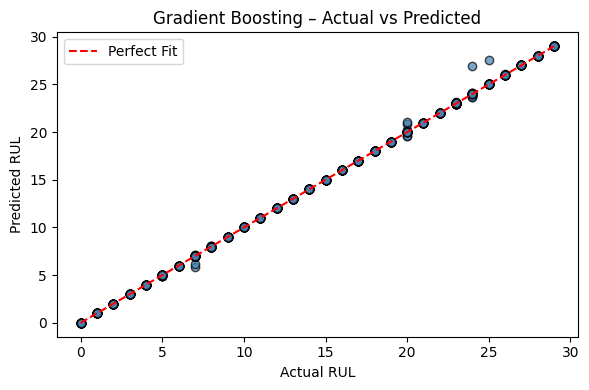

In [33]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold

# 1. Faster Cross-Validation Strategy
# With 7,500 samples, a standard 5-fold KFold is highly stable.
kf_fast = KFold(n_splits=5, shuffle=True, random_state=42)

pipeline_gb = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  GradientBoostingRegressor(random_state=42))
])

# 2. Refined Parameter Distribution
param_dist_gb = {
    "model__n_estimators":  [100, 200],      # Sufficient for this data size
    "model__learning_rate": [0.05, 0.1],     # The most effective rates
    "model__max_depth":     [3, 5],          # Prevents excessive tree depth
    "model__subsample":     [0.8, 1.0]       # Adds stochasticity for robustness
}

# 3. Use RandomizedSearchCV (The Speed Booster)
# Instead of checking all 108 combos, it picks 10 random high-probability ones.
search_gb = RandomizedSearchCV(
    pipeline_gb,
    param_distributions=param_dist_gb,
    n_iter=10,
    cv=kf_fast,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

print(" Starting Optimized Gradient Boosting Search...")
search_gb.fit(X_train, y_train)

best_gb = search_gb.best_estimator_
print(f"Best Params: {search_gb.best_params_}")

# 4. Predict and Evaluate
y_pred_gb_train = best_gb.predict(X_train)
y_pred_gb_test = best_gb.predict(X_test)

metrics_gb_train = get_metrics(y_train, y_pred_gb_train)
metrics_gb_test = get_metrics(y_test, y_pred_gb_test)

results["Gradient Boosting"] = {'Train': metrics_gb_train, 'Test': metrics_gb_test} # Added this line

print(f"\n🔹 GB Performance - Train R²: {metrics_gb_train['R²']:.4f}")
print(f"🔹 GB Performance - Test R²:  {metrics_gb_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_gb_test, "Gradient Boosting – Actual vs Predicted")

🔄 Training and comparing 12 models...

📊 Final Algorithm Comparison (Sorted by Test Accuracy):


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
7,8. KNeighborsRegressor,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
9,10. Random Forest Regressor,0.999992,0.999907,0.024512,0.083796,0.001020,0.005593
8,9. Decision Tree Regressor,1.000000,0.999885,0.000000,0.093095,0.000000,0.003333
11,12. Gradient Boosting Regressor,0.999999,0.999825,0.006789,0.114523,0.002545,0.011280
1,2. Polynomial Regressor,0.999589,0.999570,0.175426,0.179778,0.134896,0.135895
10,11. AdaBoost Regressor,0.966482,0.967467,1.583645,1.563634,1.270517,1.249029
6,7. Support Vector Regressor,0.965828,0.963333,1.599022,1.660011,1.218915,1.269717
4,5. Ridge Regressor,0.965839,0.963331,1.598752,1.660053,1.220591,1.271213
0,1. Linear Regressor,0.965845,0.963322,1.598613,1.660262,1.218962,1.269519
2,3. Multiple Linear Regressor,0.965845,0.963322,1.598613,1.660262,1.218962,1.269519


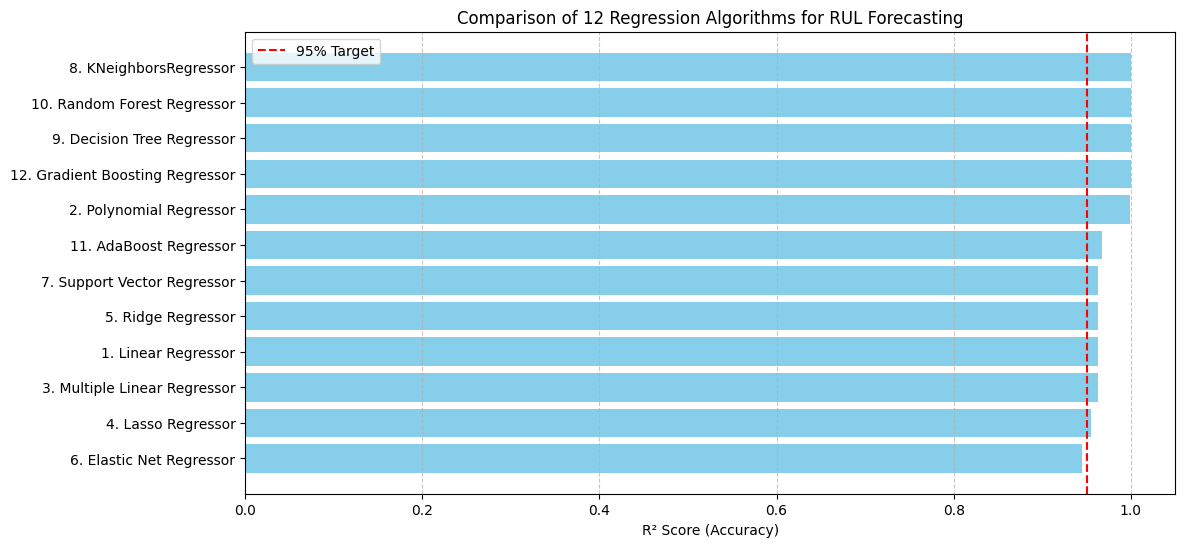

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 12 Algorithm Imports
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor

# 1. Load the Engineered Dataset
df = pd.read_csv('lifestyle_RUL_7500_ml.csv')
X = df.drop(columns=['RUL', 'cycle'])
y = df['RUL']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the 12 Algorithms
# We use Pipeline for algorithms that require scaling or feature transformation
models = {
    "1. Linear Regressor": LinearRegression(),

    "2. Polynomial Regressor": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("model", LinearRegression())
    ]),

    "3. Multiple Linear Regressor": LinearRegression(), # Same logic as LR for multiple inputs

    "4. Lasso Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1))
    ]),

    "5. Ridge Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "6. Elastic Net Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5))
    ]),

    "7. Support Vector Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVR(dual=False, loss='squared_epsilon_insensitive', C=1.0, random_state=42))
    ]),

    "8. KNeighborsRegressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5, weights='distance'))
    ]),

    "9. Decision Tree Regressor": DecisionTreeRegressor(max_depth=10, random_state=42),

    "10. Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),

    "11. AdaBoost Regressor": AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42),

    "12. Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

# 3. Training and Evaluation Loop
results_list = []

print("🔄 Training and comparing 12 models...")

for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate Metrics
    metrics = {
        'Model': name,
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    }
    results_list.append(metrics)

# 4. Generate Comparison Table
comparison_df = pd.DataFrame(results_list).sort_values(by='Test R²', ascending=False)

print("\n📊 Final Algorithm Comparison (Sorted by Test Accuracy):")
display(comparison_df.style.background_gradient(subset=['Test R²'], cmap='RdYlGn'))

# 5. Visualization for PPT
plt.figure(figsize=(12, 6))
plt.barh(comparison_df['Model'], comparison_df['Test R²'], color='skyblue')
plt.axvline(x=0.95, color='red', linestyle='--', label='95% Target')
plt.xlabel('R² Score (Accuracy)')
plt.title('Comparison of 12 Regression Algorithms for RUL Forecasting')
plt.xlim(0, 1.05)
plt.legend()
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Regression Model Comparison (Train vs. Test Metrics - Sorted by Test R²)



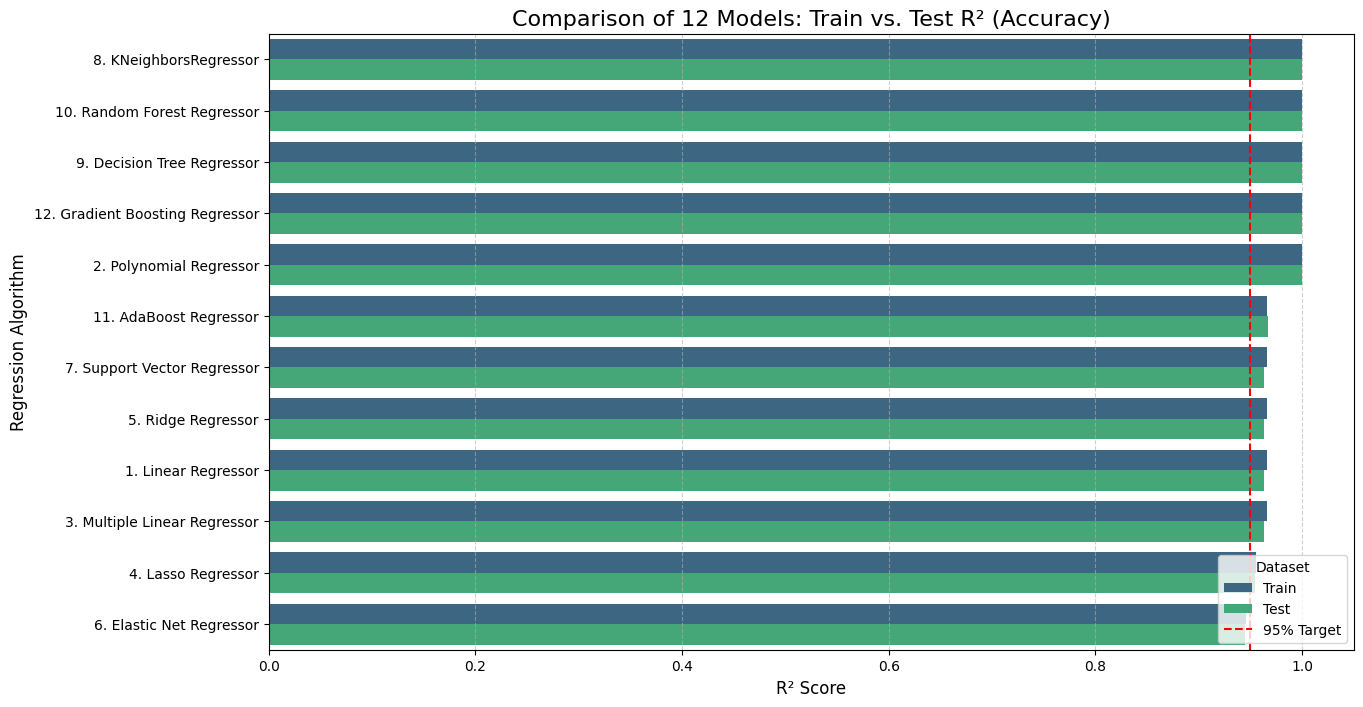

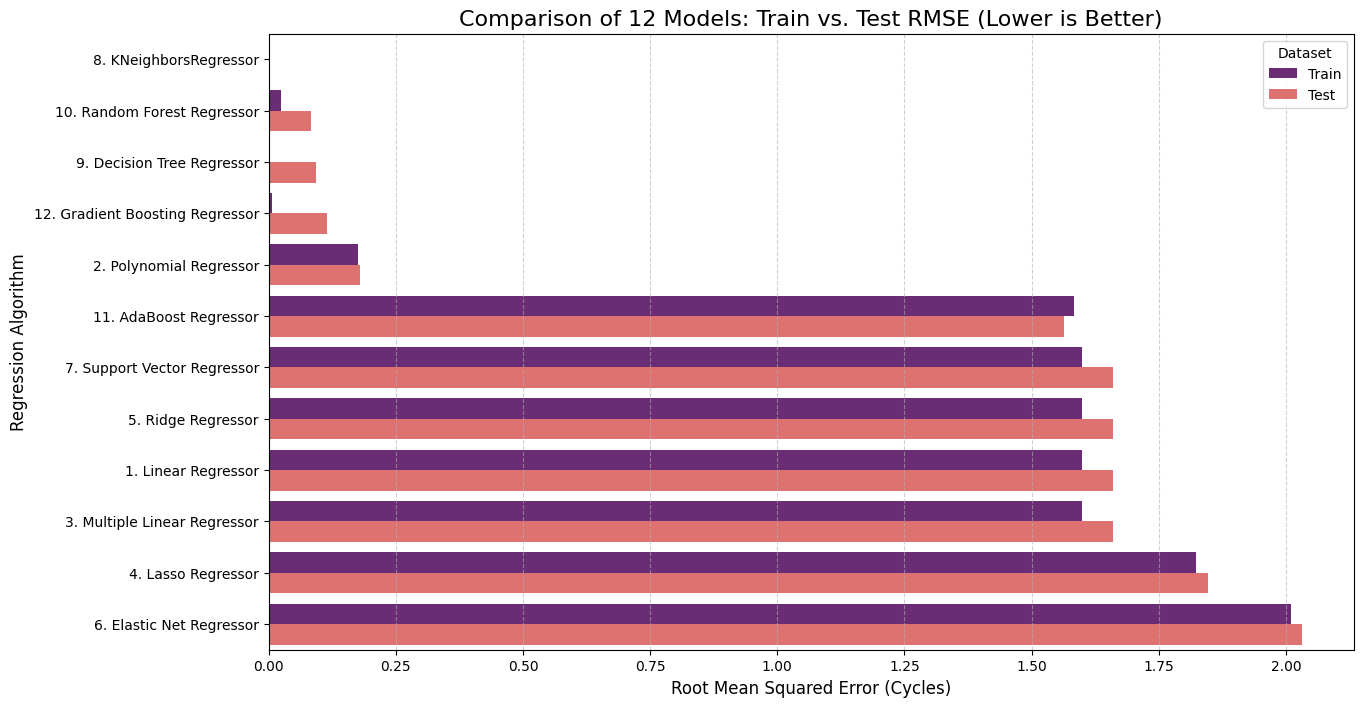

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data for plotting
# We melt the dataframe to make it compatible with seaborn's grouped bar chart (hue)

# First, identify the columns that contain the metric values
metric_cols = [col for col in comparison_df.columns if col not in ['Model']]

# Melt the DataFrame to long format
plot_df = comparison_df.melt(id_vars=['Model'],
                             value_vars=metric_cols,
                             var_name='Metric_Type_Dataset',
                             value_name='Score')

# Now, split the 'Metric_Type_Dataset' column into 'Dataset' and 'Metric'
# Example: 'Train R²' -> Dataset='Train', Metric='R²'
plot_df['Dataset'] = plot_df['Metric_Type_Dataset'].apply(lambda x: x.split(' ')[0])
plot_df['Metric'] = plot_df['Metric_Type_Dataset'].apply(lambda x: ' '.join(x.split(' ')[1:]))

# 2. Plotting R² (Accuracy Comparison)
plt.figure(figsize=(14, 8))
r2_data = plot_df[plot_df['Metric'] == 'R²']

ax1 = sns.barplot(data=r2_data, y='Model', x='Score', hue='Dataset', palette='viridis')

# Add a vertical line for your 95% target
plt.axvline(x=0.95, color='red', linestyle='--', label='95% Target')

plt.title('Comparison of 12 Models: Train vs. Test R² (Accuracy)', fontsize=16)
plt.xlabel('R² Score', fontsize=12)
plt.ylabel('Regression Algorithm', fontsize=12)
plt.legend(title='Dataset', loc='lower right')
plt.xlim(0, 1.05)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 3. Plotting RMSE (Error Comparison)
plt.figure(figsize=(14, 8))
rmse_data = plot_df[plot_df['Metric'] == 'RMSE']

ax2 = sns.barplot(data=rmse_data, y='Model', x='Score', hue='Dataset', palette='magma')

plt.title('Comparison of 12 Models: Train vs. Test RMSE (Lower is Better)', fontsize=16)
plt.xlabel('Root Mean Squared Error (Cycles)', fontsize=12)
plt.ylabel('Regression Algorithm', fontsize=12)
plt.legend(title='Dataset', loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### Convolutional Neural Network (CNN) Regressor

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
🔹 CNN Regressor - Train Performance
RMSE: 0.2085
MAE:  0.1622
R²:   0.9994

🔹 CNN Regressor - Test Performance
RMSE: 0.2093
MAE:  0.1634
R²:   0.9994


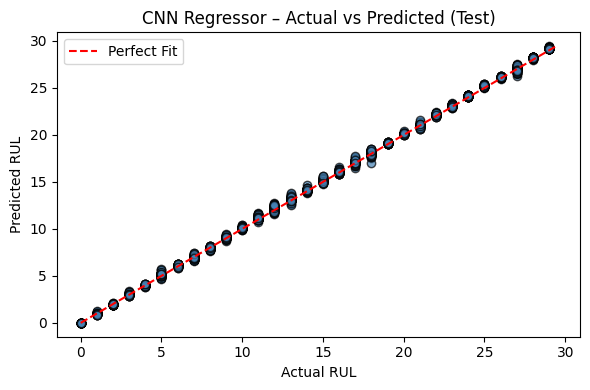

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.preprocessing import StandardScaler

# Data scaling and reshaping for Conv1D
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Define the CNN model
def create_cnn_model(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(100, activation='relu'),
        Dense(1)  # Output layer for regression
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Get input shape for CNN model
input_shape_cnn = (X_train_cnn.shape[1], X_train_cnn.shape[2]) # (timesteps, features)

cnn_model = create_cnn_model(input_shape_cnn)

# Train the CNN model
history_cnn = cnn_model.fit(X_train_cnn, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

# Predict on training and test data
y_pred_cnn_train = cnn_model.predict(X_train_cnn).flatten()
y_pred_cnn_test = cnn_model.predict(X_test_cnn).flatten()

# Evaluate performance
metrics_cnn_train = evaluate_model(y_train, y_pred_cnn_train)
metrics_cnn_test = evaluate_model(y_test, y_pred_cnn_test)

results["CNN"] = {'Train': metrics_cnn_train, 'Test': metrics_cnn_test}

print(f"🔹 CNN Regressor - Train Performance")
print(f"RMSE: {metrics_cnn_train['RMSE']:.4f}")
print(f"MAE:  {metrics_cnn_train['MAE']:.4f}")
print(f"R²:   {metrics_cnn_train['R²']:.4f}")

print(f"\n🔹 CNN Regressor - Test Performance")
print(f"RMSE: {metrics_cnn_test['RMSE']:.4f}")
print(f"MAE:  {metrics_cnn_test['MAE']:.4f}")
print(f"R²:   {metrics_cnn_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_cnn_test, "CNN Regressor – Actual vs Predicted (Test)")

### Gated Recurrent Unit (GRU) Regressor

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
🔹 GRU Regressor - Train Performance
RMSE: 0.7838
MAE:  0.5145
R²:   0.9918

🔹 GRU Regressor - Test Performance
RMSE: 0.8072
MAE:  0.5354
R²:   0.9913


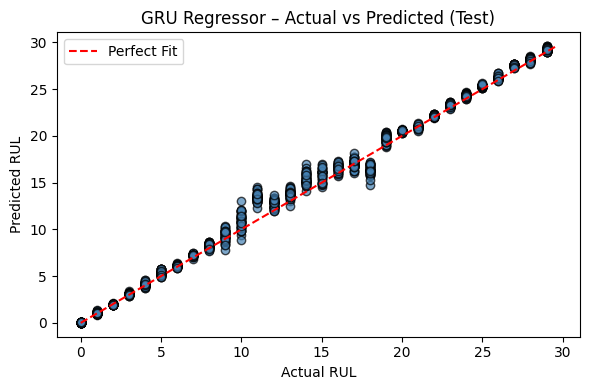

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.preprocessing import StandardScaler

# Data scaling and reshaping for GRU is the same as CNN for this tabular data structure
# X_train_scaled and X_test_scaled are already prepared from the CNN section
# Reshape to (n_samples, timesteps, features)
X_train_gru = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_gru = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Define the GRU model
def create_gru_model(input_shape):
    model = Sequential([
        GRU(units=100, activation='relu', input_shape=input_shape),
        Dense(1)  # Output layer for regression
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# Get input shape for GRU model
input_shape_gru = (X_train_gru.shape[1], X_train_gru.shape[2]) # (timesteps, features)

gru_model = create_gru_model(input_shape_gru)

# Train the GRU model
history_gru = gru_model.fit(X_train_gru, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

# Predict on training and test data
y_pred_gru_train = gru_model.predict(X_train_gru).flatten()
y_pred_gru_test = gru_model.predict(X_test_gru).flatten()

# Evaluate performance
metrics_gru_train = evaluate_model(y_train, y_pred_gru_train)
metrics_gru_test = evaluate_model(y_test, y_pred_gru_test)

results["GRU"] = {'Train': metrics_gru_train, 'Test': metrics_gru_test}

print(f"🔹 GRU Regressor - Train Performance")
print(f"RMSE: {metrics_gru_train['RMSE']:.4f}")
print(f"MAE:  {metrics_gru_train['MAE']:.4f}")
print(f"R²:   {metrics_gru_train['R²']:.4f}")

print(f"\n🔹 GRU Regressor - Test Performance")
print(f"RMSE: {metrics_gru_test['RMSE']:.4f}")
print(f"MAE:  {metrics_gru_test['MAE']:.4f}")
print(f"R²:   {metrics_gru_test['R²']:.4f}")

plot_actual_vs_predicted(y_test, y_pred_gru_test, "GRU Regressor – Actual vs Predicted (Test)")